# Hafta 7: İkili Dizi Hizalama II: Smith–Waterman, Afin Boşluk Cezası ve Yer Değiştirme Matrisleri

**Biyoenformatiğe Giriş (Python & Biopython)**

**Bu haftanın hedefleri**
1. Smith–Waterman yerel hizalama algoritmasını elle ve Python'da uygulamak.
2. Doğrusal ve afin boşluk cezalarını karşılaştırmak.
3. PAM ve BLOSUM matrislerinin log-odds mantığını anlamak; bir hizalamadan küçük bir yer değiştirme matrisi türetmek.
4. Nokta grafiği (dot plot) çizmek ve hizalama skorunun istatistiksel anlamlılığını karıştırma testiyle değerlendirmek.

**Veri:** `protein_ailesi.fasta`, `protein_ailesi_hizali.aln`

> **Kullanım:** Colab'da *Çalışma zamanı → Tümünü çalıştır* ile tüm hücreleri sırayla çalıştırabilirsiniz. Alıştırmaların çözümleri notebook'un sonundadır; önce kendiniz deneyin.

In [1]:
# Colab'da gerekli kütüphaneleri kur (yalnızca ilk çalıştırmada birkaç saniye sürer)
!pip -q install biopython 
import Bio
print('Biopython sürümü:', Bio.__version__)

Biopython sürümü: 1.88


In [2]:
# ---------------- VERİ SETİNİ HAZIRLA ----------------
# Veri dosyaları ders paketindeki 'veri' klasöründe de mevcuttur.
# İsterseniz Colab'ın sol panelinden 'veri' klasörü oluşturup dosyaları yükleyebilirsiniz;
# dosya bulunamazsa aşağıdaki fonksiyon(lar) AYNI veriyi (sabit tohum) yeniden üretir.
import os

def veri_uret_protein_ailesi(klasor="veri"):
    """protein_ailesi.fasta (hizasız), protein_ailesi_hizali.aln (gerçek MSA, Clustal)."""
    import os, random
    from Bio.Seq import Seq
    from Bio.SeqRecord import SeqRecord
    from Bio.Align import MultipleSeqAlignment
    from Bio import SeqIO, AlignIO
    os.makedirs(klasor, exist_ok=True)
    rng = random.Random(2026)
    aa = "ACDEFGHIKLMNPQRSTVWY"
    frek = [8.3, 1.4, 5.5, 6.8, 3.9, 7.1, 2.3, 5.9, 5.8, 9.7, 2.4, 4.1, 4.7, 3.9, 5.4, 6.6, 5.3, 6.9, 1.1, 2.9]
    # Yer değiştirme olasılıkları BLOSUM62'den türetilir: P(b|a) ∝ p_b * 2^(s(a,b)/2)
    from Bio.Align import substitution_matrices
    B62 = substitution_matrices.load("BLOSUM62")
    gecis = {a: [0 if b == a else frek[j] * 2 ** (B62[a][b] / 2) for j, b in enumerate(aa)] for a in aa}
    L = 160
    ata = ["M"] + rng.choices(aa, weights=frek, k=L - 1)
    korunmus = set(rng.sample(range(1, L), 35)) | {0}

    def evrim(dizi, t):
        yeni = list(dizi)
        for i in range(len(yeni)):
            if yeni[i] == "-" or i in korunmus:
                continue
            if rng.random() < t:
                yeni[i] = rng.choices(aa, weights=gecis[yeni[i]])[0]
        if rng.random() < t * 2.5:                      # delesyon olayı
            u = rng.randint(1, 5)
            b = rng.randint(5, L - u - 5)
            if not any(k in korunmus for k in range(b, b + u)):
                for k in range(b, b + u):
                    yeni[k] = "-"
        return yeni

    # ((A1,A2),(A3,(A4,A5))) , ((B1,B2),B3)
    kA = evrim(ata, 0.15); kB = evrim(ata, 0.25)
    kA1 = evrim(kA, 0.08); kA2 = evrim(kA, 0.12)
    diziler = {
        "protA1": evrim(kA1, 0.05), "protA2": evrim(kA1, 0.06),
        "protA3": evrim(kA2, 0.10), "protA4": evrim(evrim(kA2, 0.05), 0.05),
        "protA5": evrim(evrim(kA2, 0.05), 0.07),
        "protB1": evrim(kB, 0.08), "protB2": evrim(kB, 0.10), "protB3": evrim(kB, 0.20),
    }
    hizali = MultipleSeqAlignment([SeqRecord(Seq("".join(v)), id=k) for k, v in diziler.items()])
    AlignIO.write(hizali, os.path.join(klasor, "protein_ailesi_hizali.aln"), "clustal")
    kayitlar = [SeqRecord(Seq("".join(v).replace("-", "")), id=k, description="sentetik protein ailesi uyesi")
                for k, v in diziler.items()]
    ilgisiz = "M" + "".join(rng.choices(aa, weights=frek, k=149))
    kayitlar.append(SeqRecord(Seq(ilgisiz), id="ilgisiz1", description="aileyle akraba olmayan rastgele protein"))
    SeqIO.write(kayitlar, os.path.join(klasor, "protein_ailesi.fasta"), "fasta")


if not os.path.exists('veri/protein_ailesi.fasta'):
    veri_uret_protein_ailesi()
print('veri klasörü:', sorted(os.listdir('veri')))


veri klasörü: ['1A8O.pdb', 'protein_ailesi.fasta', 'protein_ailesi_hizali.aln']


## 1. Smith–Waterman yerel hizalama
NW'den üç farkı vardır:
1. İlk satır/sütun **0** ile başlar.
2. Hücre değeri negatif olamaz: $F(i,j)=\max\{0,\ F(i-1,j-1)+s,\ F(i-1,j)+g,\ F(i,j-1)+g\}$
3. Geri izleme **matristeki en büyük değerden** başlar ve **0'a ulaşınca** durur.

### Elle örnek (klasik): x = `TGTTACGG`, y = `GGTTGACTA`
Puanlama: eşleşme +3, uyumsuzluk −3, boşluk −2.

|   | – | G | G | T | T | G | A | C | T | A |
|---|---|---|---|---|---|---|---|---|---|---|
| – | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 0 |
| T | 0 | 0 | 0 | 3 | 3 | 1 | 0 | 0 | 3 | 1 |
| G | 0 | 3 | 3 | 1 | 1 | 6 | 4 | 2 | 1 | 0 |
| T | 0 | 1 | 1 | 6 | 4 | 4 | 3 | 1 | 5 | 3 |
| T | 0 | 0 | 0 | 4 | 9 | 7 | 5 | 3 | 4 | 2 |
| A | 0 | 0 | 0 | 2 | 7 | 6 | 10 | 8 | 6 | 7 |
| C | 0 | 0 | 0 | 0 | 5 | 4 | 8 | **13** | 11 | 9 |
| G | 0 | 3 | 3 | 1 | 3 | 8 | 6 | 11 | 10 | 8 |
| G | 0 | 3 | 6 | 4 | 2 | 6 | 5 | 9 | 8 | 7 |

En yüksek değer 13 → geri izleme: `GTT-AC` / `GTTGAC` (5 eşleşme × 3 + 1 boşluk × (−2) = 13).

In [3]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from Bio import Align, SeqIO, AlignIO

def smith_waterman(x, y, e=3, u=-3, g=-2):
    m, n = len(x), len(y)
    H = np.zeros((m + 1, n + 1), dtype=int)
    for i in range(1, m + 1):
        for j in range(1, n + 1):
            s = e if x[i - 1] == y[j - 1] else u
            H[i, j] = max(0, H[i - 1, j - 1] + s, H[i - 1, j] + g, H[i, j - 1] + g)
    i, j = np.unravel_index(np.argmax(H), H.shape)
    skor = H[i, j]
    a1, a2 = [], []
    while H[i, j] > 0:
        s = e if x[i - 1] == y[j - 1] else u
        if H[i, j] == H[i - 1, j - 1] + s:
            a1.append(x[i - 1]); a2.append(y[j - 1]); i -= 1; j -= 1
        elif H[i, j] == H[i - 1, j] + g:
            a1.append(x[i - 1]); a2.append("-"); i -= 1
        else:
            a1.append("-"); a2.append(y[j - 1]); j -= 1
    return H, int(skor), "".join(reversed(a1)), "".join(reversed(a2)), (int(i), int(j))

H, skor, h1, h2, bas = smith_waterman("TGTTACGG", "GGTTGACTA")
print(pd.DataFrame(H, index=["-"] + list("TGTTACGG"), columns=["-"] + list("GGTTGACTA")))
print(f"\nSkor={skor}, başlangıç (i,j)={bas}\n{h1}\n{h2}")

   -  G  G  T  T  G   A   C   T  A
-  0  0  0  0  0  0   0   0   0  0
T  0  0  0  3  3  1   0   0   3  1
G  0  3  3  1  1  6   4   2   1  0
T  0  1  1  6  4  4   3   1   5  3
T  0  0  0  4  9  7   5   3   4  2
A  0  0  0  2  7  6  10   8   6  7
C  0  0  0  0  5  4   8  13  11  9
G  0  3  3  1  3  8   6  11  10  8
G  0  3  6  4  2  6   5   9   8  7

Skor=13, başlangıç (i,j)=(1, 1)
GTT-AC
GTTGAC


In [4]:
yerel = Align.PairwiseAligner(mode="local", match_score=3, mismatch_score=-3, gap_score=-2)
a = yerel.align("TGTTACGG", "GGTTGACTA")[0]
print("Biopython skoru:", a.score)
print(a)

Biopython skoru: 13.0
target            1 GTT-AC 6
                  0 |||-|| 6
query             1 GTTGAC 7



### Global mi yerel mi?
Uzun bir dizinin içinde korunmuş kısa bir bölge (ör. bir protein domeni) aranıyorsa **yerel** hizalama doğru seçimdir.

In [5]:
import random
random.seed(4)
domen = "WKCGGHRLVDYE"
uzun1 = "".join(random.choices("ACDEFGHIKLMNPQRSTVWY", k=40)) + domen + "".join(random.choices("ACDEFGHIKLMNPQRSTVWY", k=30))
uzun2 = "".join(random.choices("ACDEFGHIKLMNPQRSTVWY", k=15)) + domen.replace("L", "I") + "".join(random.choices("ACDEFGHIKLMNPQRSTVWY", k=50))
glob = Align.PairwiseAligner(mode="global", match_score=3, mismatch_score=-1, gap_score=-2)
print("GLOBAL:\n", glob.align(uzun1, uzun2)[0])
print("YEREL:\n", yerel.align(uzun1, uzun2)[0])

GLOBAL:
 target            0 FDIECKWTSFM-GEDFWTTTEHPRVVCPQMELCWVMHWNVTW-KCGGHRLVDYEM-KNK-
                  0 |.-|.......-|...|....|-|.|..--|--|.-----|.-|...|.......-|..-
query             0 FH-ELAQVYRYAGYSKWKCGGH-RIVDY--E--WP-----TGEKDIYHAAESIGCYKFCC

target           56 EHTAAPG-MLHYE-KFPGIRHNWDCFSP 82
                 60 |..|...-|..|.-|..........|.. 88
query            49 EQDALFYDMSKYLFKAKFVTLAGFFFVD 77

YEREL:
 target           40 WKCGGHRLVDYE 52
                  0 |||||||.|||| 12
query            15 WKCGGHRIVDYE 27



## 2. Afin (affine) boşluk cezası
Biyolojide bir indel olayı genellikle **birden fazla** bazı/amino asidi birlikte etkiler. Bu yüzden
tek uzun boşluk, birçok kısa boşluktan daha olasıdır.

| Model | *k* uzunluklu boşluğun cezası |
|---|---|
| Doğrusal | $w(k) = k\cdot g$ |
| Afin | $w(k) = o + (k-1)\cdot e$ &nbsp; (o: açma, e: uzatma; \|o\| > \|e\|) |

**Sayısal örnek:** o = −10, e = −1 için 3 uzunluklu tek boşluk: −10 −1 −1 = **−12**; üç ayrı tek boşluk: 3 × (−10) = **−30**.
Doğrusal g = −4 ile her ikisi de −12 olurdu → afin model tek boşluğu açıkça tercih eder.

Gotoh (1982) algoritması afin cezayı üç matrisle ($M$, $I_x$, $I_y$) yine $O(mn)$ zamanda çözer.

In [6]:
x = "TCATGTATGCCTTAGATC"
y = "TCATTTTTCGATC"             # ortadan 5 baz silinmiş + bir nokta mutasyonu
dogrusal = Align.PairwiseAligner(mode="global", match_score=2, mismatch_score=-1, gap_score=-2)
afin = Align.PairwiseAligner(mode="global", match_score=2, mismatch_score=-1, open_gap_score=-5, extend_gap_score=-0.5)
for ad, h in [("doğrusal", dogrusal), ("afin", afin)]:
    al = h.align(x, y)
    print(f"{ad}: skor={al.score}, optimal hizalama sayısı={len(al)}")
    print(al[0])

doğrusal: skor=13.0, optimal hizalama sayısı=1
target            0 TCATGTATGCCTTAGATC 18
                  0 ||||-|-|---||.|||| 18
query             0 TCAT-T-T---TTCGATC 13

afin: skor=13.0, optimal hizalama sayısı=1
target            0 TCATGTATGCCTTAGATC 18
                  0 ||||.|-----||.|||| 18
query             0 TCATTT-----TTCGATC 13



## 3. Yer değiştirme (substitution) matrisleri
Proteinlerde bazı yer değiştirmeler (ör. I↔L, ikisi de hidrofobik) diğerlerinden (ör. W↔G) çok daha sık görülür.

**Log-odds skoru:** $s(a,b) = \dfrac{1}{\lambda}\log\dfrac{q_{ab}}{p_a\,p_b}$

* $q_{ab}$: güvenilir hizalamalarda a–b çiftinin gözlenen frekansı
* $p_a p_b$: iki amino asidin rastlantısal olarak karşılaşma olasılığı
* Skor > 0 → çift beklenenden sık (muhafazakâr değişim)

| Matris ailesi | Nasıl türetildi? | Yakın akraba için | Uzak akraba için |
|---|---|---|---|
| PAM (Dayhoff, 1978) | Çok yakın dizilerden evrimsel model, matris kuvvetleri | PAM30 | PAM250 |
| BLOSUM (Henikoff, 1992) | Korunmuş bloklar, %X özdeşlikte kümeleme | BLOSUM80 | BLOSUM45 |

BLOSUM62: BLAST'ın varsayılan protein matrisi. *Sayı büyüdükçe BLOSUM daha yakın akrabalar içindir; PAM'da tersi.*

In [7]:
from Bio.Align import substitution_matrices
print(substitution_matrices.load())          # mevcut matrisler
B62 = substitution_matrices.load("BLOSUM62")
print(B62)

['BENNER22', 'BENNER6', 'BENNER74', 'BLASTN', 'BLASTP', 'BLOSUM45', 'BLOSUM50', 'BLOSUM62', 'BLOSUM80', 'BLOSUM90', 'DAYHOFF', 'FENG', 'GENETIC', 'GONNET1992', 'HOXD70', 'JOHNSON', 'JONES', 'LEVIN', 'MCLACHLAN', 'MDM78', 'MEGABLAST', 'NUC.4.4', 'PAM250', 'PAM30', 'PAM70', 'RAO', 'RISLER', 'SCHNEIDER', 'STR', 'TRANS']
#  Matrix made by matblas from blosum62.iij
#  * column uses minimum score
#  BLOSUM Clustered Scoring Matrix in 1/2 Bit Units
#  Blocks Database = /data/blocks_5.0/blocks.dat
#  Cluster Percentage: >= 62
#  Entropy =   0.6979, Expected =  -0.5209
     A    R    N    D    C    Q    E    G    H    I    L    K    M    F    P    S    T    W    Y    V    B    Z    X    *
A  4.0 -1.0 -2.0 -2.0  0.0 -1.0 -1.0  0.0 -2.0 -1.0 -1.0 -1.0 -1.0 -2.0 -1.0  1.0  0.0 -3.0 -2.0  0.0 -2.0 -1.0  0.0 -4.0
R -1.0  5.0  0.0 -2.0 -3.0  1.0  0.0 -2.0  0.0 -3.0 -2.0  2.0 -1.0 -3.0 -2.0 -1.0 -1.0 -3.0 -2.0 -3.0 -1.0  0.0 -1.0 -4.0
N -2.0  0.0  6.0  1.0 -3.0  0.0  0.0  0.0  1.0 -3.0 -3.0  0.0 -2.0 

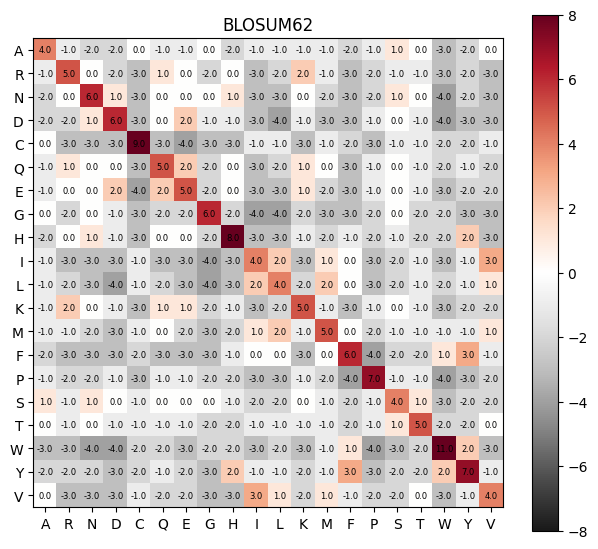

IL 2.0 | IV 3.0 | DE 2.0 | KR 2.0 | WG -2.0 | WW 11.0 | CC 9.0 | AA 4.0 | 

In [8]:
sira = "ARNDCQEGHILKMFPSTWYV"
Bm = np.array([[B62[a][b] for b in sira] for a in sira])
plt.figure(figsize=(6.4, 5.6))
plt.imshow(Bm, cmap="RdGy_r", vmin=-8, vmax=8)
plt.xticks(range(20), list(sira)); plt.yticks(range(20), list(sira))
for i in range(20):
    for j in range(20):
        plt.text(j, i, Bm[i, j], ha="center", va="center", fontsize=6)
plt.title("BLOSUM62"); plt.colorbar(); plt.tight_layout(); plt.show()
for cift in ["IL", "IV", "DE", "KR", "WG", "WW", "CC", "AA"]:
    print(cift, B62[cift[0]][cift[1]], end=" | ")

### Sayısal örnek — Mini yer değiştirme matrisi türetmek
Bir hizalama sütununda 4 dizi `L, L, I, V` olsun. Çiftler: (L,L), (L,I)×2, (L,V)×2, (I,V) → toplam 6 çift.

| Çift | Gözlenen $q_{ab}$ | Harf frekansları: $p_L=2/4, p_I=1/4, p_V=1/4$ | Beklenen $e_{ab}$ | $\log_2(q/e)$ |
|---|---|---|---|---|
| L–L | 1/6 = 0.167 | $p_L^2$ | 0.25 | −0.58 |
| L–I | 2/6 = 0.333 | $2p_Lp_I$ | 0.25 | +0.42 |
| L–V | 2/6 = 0.333 | $2p_Lp_V$ | 0.25 | +0.42 |
| I–V | 1/6 = 0.167 | $2p_Ip_V$ | 0.125 | +0.42 |

Gerçek matrisler binlerce sütundan bu şekilde türetilir. Aşağıda kendi protein ailemizin **gerçek hizalamasından** bir matris türetiyoruz.

LL: bizim=  4.73   BLOSUM62=4.0
LI: bizim= -1.09   BLOSUM62=2.0
KR: bizim=  0.04   BLOSUM62=2.0
DE: bizim=  2.02   BLOSUM62=2.0
WW: bizim= 11.35   BLOSUM62=11.0
WG: bizim=  0.30   BLOSUM62=-2.0
AG: bizim= -0.72   BLOSUM62=0.0


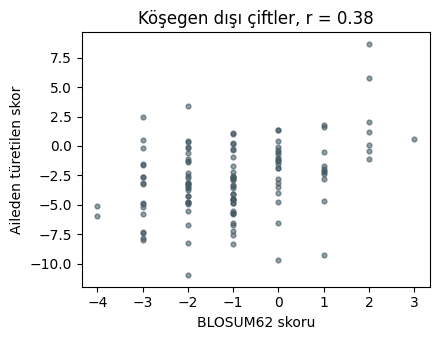

Not: veri küçük olduğundan nadir çiftlerin skorları gürültülüdür; gerçek BLOSUM binlerce bloktan türetilir.


In [9]:
from collections import Counter
from itertools import combinations

msa = AlignIO.read("veri/protein_ailesi_hizali.aln", "clustal")
cift, tekil = Counter(), Counter()
for j in range(msa.get_alignment_length()):
    sutun = [c for c in msa[:, j] if c != "-"]
    tekil.update(sutun)
    for a, b in combinations(sutun, 2):
        cift[tuple(sorted((a, b)))] += 1
N_cift, N_tek = sum(cift.values()), sum(tekil.values())
p = {a: tekil[a] / N_tek for a in tekil}

def skor(a, b):
    q = cift[tuple(sorted((a, b)))] / N_cift
    e = p[a] * p[b] * (1 if a == b else 2)
    return 2 * np.log2(q / e) if q > 0 else np.nan     # yarım-bit birimi (BLOSUM gibi)

for c in ["LL", "LI", "KR", "DE", "WW", "WG", "AG"]:
    print(f"{c}: bizim={skor(c[0], c[1]):6.2f}   BLOSUM62={B62[c[0]][c[1]]}")
# Tüm çiftler için BLOSUM62 ile karşılaştırma
xs, ys = [], []
for a, b in combinations(sorted(p), 2):
    v = skor(a, b)
    if not np.isnan(v):
        xs.append(B62[a][b]); ys.append(v)
r = np.corrcoef(xs, ys)[0, 1]
plt.figure(figsize=(4.5, 3.5)); plt.scatter(xs, ys, s=12, color="#455a64", alpha=0.6)
plt.xlabel("BLOSUM62 skoru"); plt.ylabel("Aileden türetilen skor"); plt.title(f"Köşegen dışı çiftler, r = {r:.2f}")
plt.tight_layout(); plt.show()
print("Not: veri küçük olduğundan nadir çiftlerin skorları gürültülüdür; gerçek BLOSUM binlerce bloktan türetilir.")

## 4. Proteinleri BLOSUM62 ve afin boşlukla hizalamak

In [10]:
prot = {r.id: r.seq for r in SeqIO.parse("veri/protein_ailesi.fasta", "fasta")}
hb = Align.PairwiseAligner(mode="local", substitution_matrix=B62, open_gap_score=-11, extend_gap_score=-1)
a = hb.align(prot["protA1"], prot["protB3"])[0]
print("Skor:", a.score)
print(a)

Skor: 370.0
target            0 MDLLTDFNLSLRRRMSNDSKSQQEHDVSYVAYLKKTQMAQIKIMLDLRNLVFRVIAAFDA
                  0 |.|.|||||||.||..|||||||---|.|.|.|.|||||.|.|.||.|.|||.|..|.|.
query             0 MLLITDFNLSLMRRVFNDSKSQQ---VDYLAHLGKTQMAKIRITLDNRGLVFKVLSAQDL

target           60 QGDTILYTNKEVLLLPASLLKKNGAPNKILVGLLPELVSGVDESLVWYTLDGLCAIKAAL
                 60 |..-..........|..||..|.|||||..|||...|.|||..||....|.|||.||.|.
query            57 QRN-LMMVQEPIYELYGSLVTKGGAPNKMYVGLTKSLDSGVQQSLLRWKLAGLCQIKHAD

target          120 VCSFNRVPPQGMRKLRDLMVPFTPVSVG--LEGDTAHIRA 158
                120 |||||...|..||.|.|.||...||..|--.|.||||||| 160
query           116 VCSFNYLVPEEMRVLPDFMVTLDPVGIGKSSEADTAHIRA 156



## 5. Nokta grafiği (dot plot)
İki dizi bir matrisin eksenlerine yerleştirilir; *w* uzunluklu pencerede en az *s* eşleşme varsa nokta konur.
Köşegen çizgiler benzer bölgeleri, kaymalar indelleri, ters köşegenler ters tekrarları gösterir.

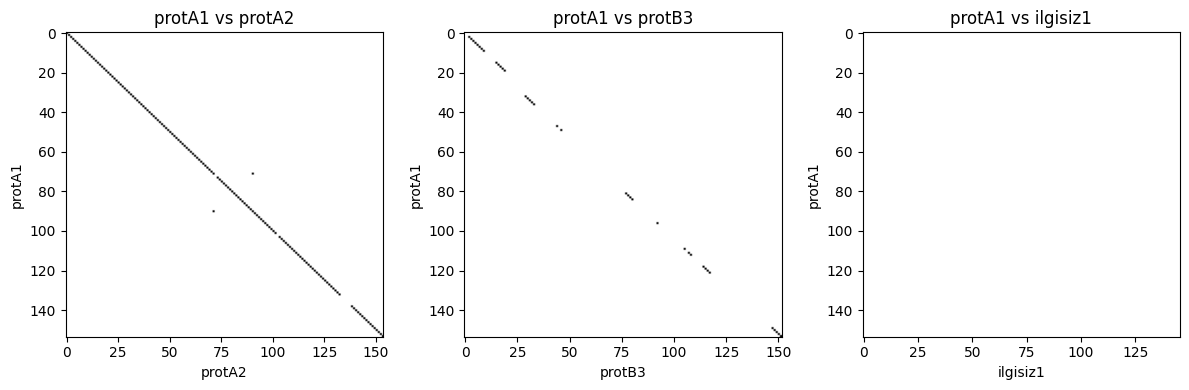

In [11]:
def dot_plot(a, b, w=5, s=4):
    a, b = str(a), str(b)
    M = np.zeros((len(a) - w + 1, len(b) - w + 1))
    for i in range(M.shape[0]):
        for j in range(M.shape[1]):
            if sum(x == y for x, y in zip(a[i:i + w], b[j:j + w])) >= s:
                M[i, j] = 1
    return M

fig, ax = plt.subplots(1, 3, figsize=(12, 4))
for k, (i, j) in enumerate([("protA1", "protA2"), ("protA1", "protB3"), ("protA1", "ilgisiz1")]):
    ax[k].imshow(dot_plot(prot[i], prot[j]), cmap="Greys", aspect="auto")
    ax[k].set_title(f"{i} vs {j}"); ax[k].set_xlabel(j); ax[k].set_ylabel(i)
plt.tight_layout(); plt.show()

## 6. Skor anlamlı mı? Karıştırma (shuffle) testi ve z-skoru
Aynı kompozisyona sahip ama sırası karıştırılmış dizilerle hizalama yapılır:
$z = \dfrac{S_{gerçek} - \bar{S}_{karışık}}{\sigma_{karışık}}$. Kabaca z > 5 güçlü benzerlik işaretidir.
(Yerel hizalama skorları normal değil **aşırı değer (Gumbel)** dağılımına uyar — BLAST'ın E-değeri buna dayanır, 8. hafta.)

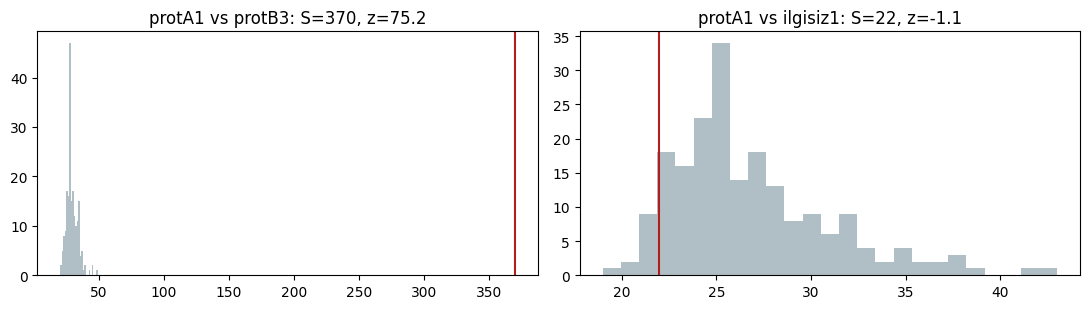

In [12]:
def karistirma_testi(a, b, n=200, tohum=0):
    rng = random.Random(tohum)
    gercek = hb.score(a, b)
    liste = list(str(b)); skorlar = []
    for _ in range(n):
        rng.shuffle(liste)
        skorlar.append(hb.score(a, "".join(liste)))
    skorlar = np.array(skorlar)
    return gercek, skorlar, (gercek - skorlar.mean()) / skorlar.std()

fig, ax = plt.subplots(1, 2, figsize=(11, 3.2))
for k, hedef in enumerate(["protB3", "ilgisiz1"]):
    g, sk, z = karistirma_testi(prot["protA1"], prot[hedef])
    ax[k].hist(sk, bins=25, color="#b0bec5"); ax[k].axvline(g, color="#b71c1c")
    ax[k].set_title(f"protA1 vs {hedef}: S={g:.0f}, z={z:.1f}")
plt.tight_layout(); plt.show()

## 7. Alıştırmalar
1. `ACACACTA` ve `AGCACACA` dizilerini (eşleşme +2, uyumsuzluk −1, boşluk −1) Smith–Waterman ile **elle** hizalayın; kodla doğrulayın.
2. o = −8, e = −2 afin cezasıyla 1, 2, 5 ve 10 uzunluklu boşlukların cezasını hesaplayın; doğrusal g = −4 ile karşılaştıran bir grafik çizin.
3. `protA1`–`protB1` hizalamasını BLOSUM45, BLOSUM62 ve BLOSUM80 ile yapın; skorları ve hizalama uzunluklarını tabloya dökün.
4. Nokta grafiği fonksiyonunda pencere (*w*) ve eşik (*s*) değerlerini değiştirerek gürültü–duyarlılık dengesini gözlemleyin.
5. Bir DNA dizisini ve **ters tamamlayıcısını** kendisiyle nokta grafiğinde karşılaştırın; ters tekrar içeren bir dizi (ör. `GAATTCxxxxGAATTC`) tasarlayıp gösterin.

---
## Çözümler

1) skor: 12 | A-CACACTA / AGCACAC-A
   Biopython: 12.0


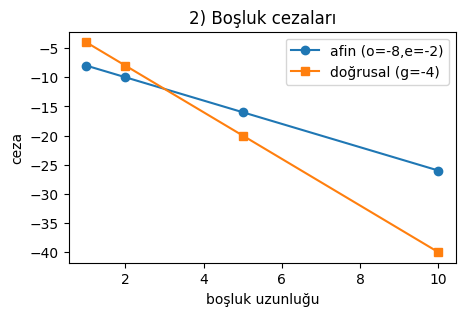

     matris   skor  hizalama uzunluğu  özdeş
0  BLOSUM45  531.0                160     93
1  BLOSUM62  430.0                160     93
2  BLOSUM80  690.0                160     93


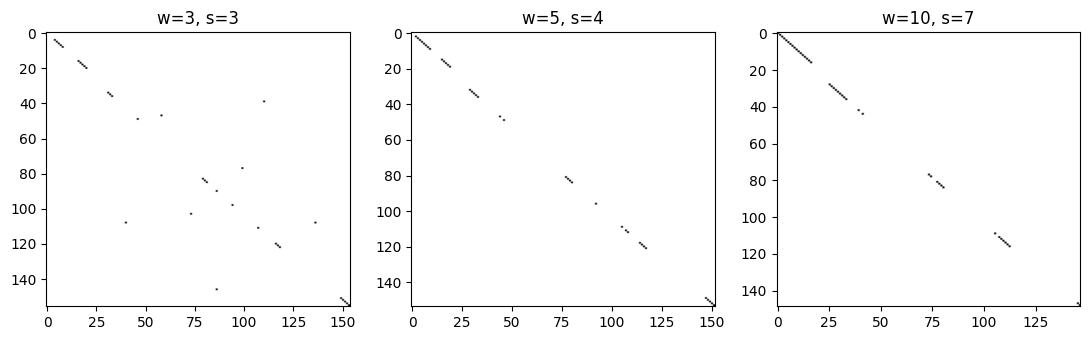

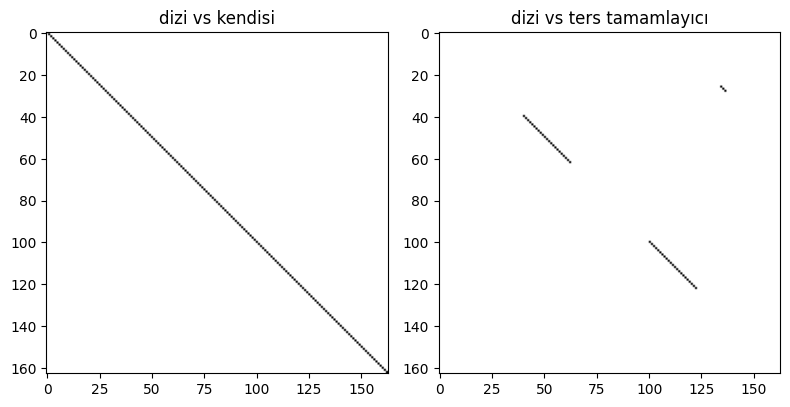

In [13]:
# 1
H1, s1_, a1_, b1_, _ = smith_waterman("ACACACTA", "AGCACACA", e=2, u=-1, g=-1)
print("1) skor:", s1_, "|", a1_, "/", b1_)
print("   Biopython:", Align.PairwiseAligner(mode="local", match_score=2, mismatch_score=-1, gap_score=-1).score("ACACACTA", "AGCACACA"))
# 2
k = np.array([1, 2, 5, 10])
plt.figure(figsize=(5, 3)); plt.plot(k, -8 + (k - 1) * -2, "o-", label="afin (o=-8,e=-2)"); plt.plot(k, -4 * k, "s-", label="doğrusal (g=-4)")
plt.xlabel("boşluk uzunluğu"); plt.ylabel("ceza"); plt.legend(); plt.title("2) Boşluk cezaları"); plt.show()
# 3
satir = []
for ad in ["BLOSUM45", "BLOSUM62", "BLOSUM80"]:
    h = Align.PairwiseAligner(mode="local", substitution_matrix=substitution_matrices.load(ad), open_gap_score=-11, extend_gap_score=-1)
    al = h.align(prot["protA1"], prot["protB1"])[0]
    satir.append({"matris": ad, "skor": al.score, "hizalama uzunluğu": al.shape[1], "özdeş": al.counts().identities})
print(pd.DataFrame(satir))
# 4
fig, ax = plt.subplots(1, 3, figsize=(11, 3.5))
for k_, (w, s) in enumerate([(3, 3), (5, 4), (10, 7)]):
    ax[k_].imshow(dot_plot(prot["protA1"], prot["protB3"], w, s), cmap="Greys", aspect="auto"); ax[k_].set_title(f"w={w}, s={s}")
plt.tight_layout(); plt.show()
# 5
from Bio.Seq import Seq
random.seed(2)
parca = "".join(random.choices("ACGT", k=30))
d = "".join(random.choices("ACGT", k=40)) + parca + "".join(random.choices("ACGT", k=30)) + str(Seq(parca).reverse_complement()) + "".join(random.choices("ACGT", k=40))
fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].imshow(dot_plot(d, d, 8, 8), cmap="Greys"); ax[0].set_title("dizi vs kendisi")
ax[1].imshow(dot_plot(d, Seq(d).reverse_complement(), 8, 8), cmap="Greys"); ax[1].set_title("dizi vs ters tamamlayıcı")
plt.tight_layout(); plt.show()